In [3]:
# 필요한 패키지 설치

import matplotlib.pyplot as plt
import pandas as pd
import datetime
import seaborn as sns
import numpy as np
from math import pi
from pandas.plotting import parallel_coordinates
plt.rcParams['figure.dpi'] = 300

In [4]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/umutalpaydn/nba-20202021-season-player-stats
df = pd.read_csv("/content/nba2021_advanced.csv")

# 데이터 샘플 확인
df.head()

,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,FTr,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,Precious Achiuwa,PF,21,MIA,28,408,15.1,0.599,0.000,0.541,...,16.1,19.7,0.3,0.6,0.9,0.101,-2.8,-0.2,-3.0,-0.1
1,Jaylen Adams,PG,24,MIL,6,17,-6.9,0.125,0.250,0.000,...,0.0,19.7,-0.1,0.0,-0.1,-0.265,-15.6,-5.2,-20.9,-0.1
2,Steven Adams,C,27,NOP,27,760,15.9,0.592,0.006,0.397,...,20.1,12.8,1.2,0.5,1.7,0.109,-0.1,-1.0,-1.1,0.2
3,Bam Adebayo,C,23,MIA,26,873,22.7,0.641,0.015,0.469,...,16.2,24.6,2.3,1.3,3.6,0.196,2.9,2.0,4.9,1.5
4,LaMarcus Aldridge,C,35,SAS,18,480,15.2,0.542,0.298,0.093,...,6.4,22.3,0.2,0.5,0.7,0.075,0.3,-1.0,-0.7,0.2


In [5]:
# 히트맵 시각화 V1을 위한 데이터 전처리

# 5개 팀만 필터링
df1 = df[df['Tm'].isin(['ATL','BOS','BRK','CHI','CHO'])]

# 6개 컬럼만 필터링
df1 = df1[['Tm', 'ORB%','TRB%','AST%','BLK%','USG%']]

#  팀 별 요소 평균 전처리
df1 = df1.groupby('Tm').mean()
df1.head()

,ORB%,TRB%,AST%,BLK%,USG%
Tm,,,,,
ATL,5.250000,10.400000,13.893750,1.718750,18.412500
BOS,5.681250,10.362500,12.881250,2.437500,18.325000
BRK,4.394737,10.547368,15.210526,2.147368,18.868421
CHI,4.482353,10.976471,13.500000,1.405882,17.582353
CHO,7.628571,11.742857,14.900000,2.764286,19.357143


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  497 non-null    object 
 1   Pos     497 non-null    object 
 2   Age     497 non-null    int64  
 3   Tm      497 non-null    object 
 4   G       497 non-null    int64  
 5   MP      497 non-null    int64  
 6   PER     497 non-null    float64
 7   TS%     497 non-null    float64
 8   3PAr    497 non-null    float64
 9   FTr     497 non-null    float64
 10  ORB%    497 non-null    float64
 11  DRB%    497 non-null    float64
 12  TRB%    497 non-null    float64
 13  AST%    497 non-null    float64
 14  STL%    497 non-null    float64
 15  BLK%    497 non-null    float64
 16  TOV%    497 non-null    float64
 17  USG%    497 non-null    float64
 18  OWS     497 non-null    float64
 19  DWS     497 non-null    float64
 20  WS      497 non-null    float64
 21  WS/48   497 non-null    float64
 22  OB

In [14]:
df.describe()

,Age,G,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
count,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,...,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,25.623742,18.456740,417.867203,12.646278,0.538622,0.405203,0.274288,4.844668,15.410060,10.134004,...,13.473843,18.752113,0.460563,0.425956,0.883702,0.067598,-1.587123,-0.538632,-2.128169,0.185111
std,4.054229,8.311394,297.732077,7.404316,0.130926,0.234554,0.270251,4.654288,7.162096,5.058663,...,9.487660,5.916145,0.784665,0.382150,1.037034,0.118702,4.501388,1.741360,5.407418,0.492831
min,19.000000,1.000000,2.000000,-40.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.000000,-1.200000,-0.100000,-0.800000,-1.128000,-40.100000,-9.200000,-47.100000,-0.700000
25%,22.000000,12.000000,130.000000,9.300000,0.500000,0.253000,0.142000,1.800000,10.800000,6.600000,...,9.300000,14.500000,0.000000,0.100000,0.100000,0.030000,-3.200000,-1.500000,-3.800000,-0.100000
50%,25.000000,20.000000,419.000000,12.600000,0.556000,0.418000,0.226000,3.200000,14.200000,9.100000,...,12.000000,18.000000,0.200000,0.300000,0.600000,0.083000,-1.200000,-0.500000,-1.600000,0.000000
75%,28.000000,26.000000,667.000000,16.700000,0.607000,0.563000,0.318000,6.600000,19.100000,12.700000,...,15.700000,22.300000,0.700000,0.700000,1.300000,0.129000,0.800000,0.400000,0.500000,0.300000
max,37.000000,30.000000,1101.000000,38.700000,1.500000,1.000000,2.667000,35.000000,54.100000,28.000000,...,100.000000,41.300000,4.900000,2.100000,6.300000,0.342000,14.100000,7.100000,18.000000,3.400000


In [16]:
df.skew(numeric_only = True)

,0
Age,0.510879
G,-0.454750
MP,0.235792
PER,-1.253534
TS%,-0.705665
3PAr,0.038022
FTr,4.190581
ORB%,1.816092
DRB%,0.858006
TRB%,0.959213


In [17]:
df.kurtosis(numeric_only = True)

,0
Age,-0.470464
G,-1.028589
MP,-1.131211
PER,7.158630
TS%,10.261389
3PAr,-0.509360
FTr,25.691326
ORB%,4.763801
DRB%,1.824121
TRB%,0.945366


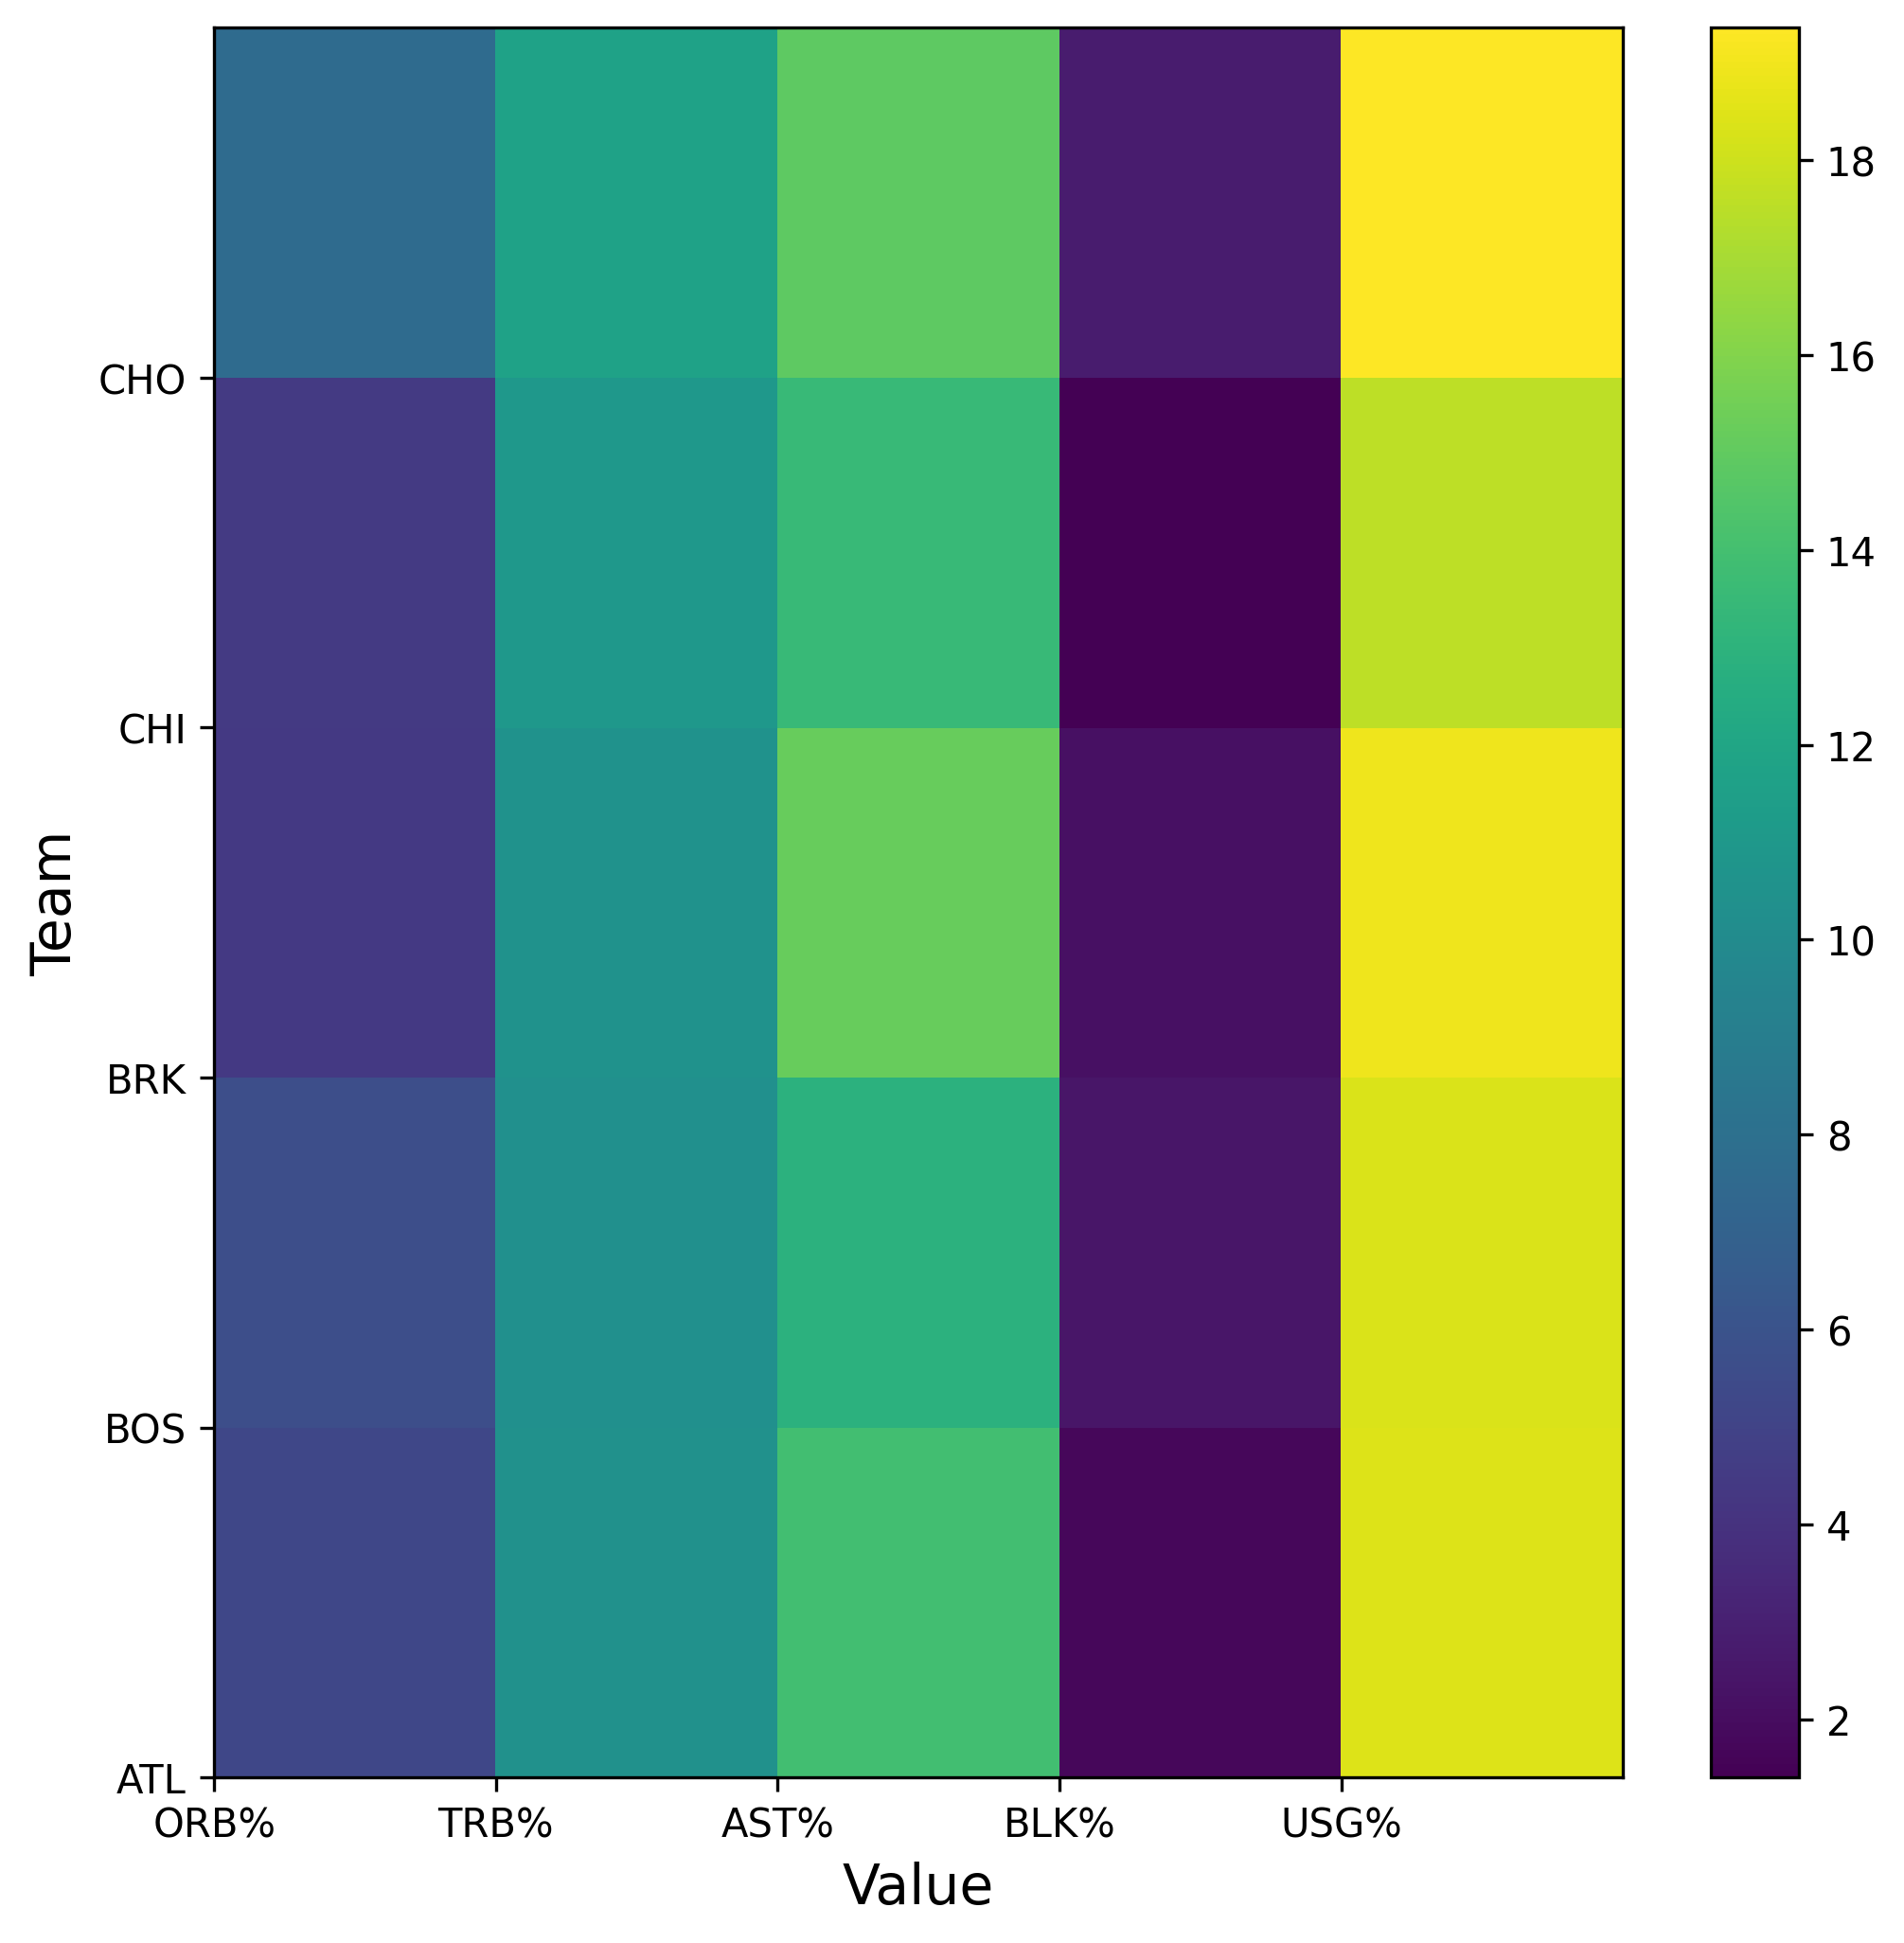

In [6]:
# 히트맵 시각화 V1

fig = plt.figure(figsize=(8,8))
fig.set_facecolor('white')
plt.pcolor(df1.values)

# x축 컬럼 설정
plt.xticks(range(len(df1.columns)),df1.columns)
# y축 컬럼 설정
plt.yticks(range(len(df1.index)), df1.index)
# x축 레이블 설정
plt.xlabel('Value', fontsize=14)
# y축 레이블 설정
plt.ylabel('Team', fontsize=14)
plt.colorbar()
plt.show()

In [7]:
# 히트맵 시각화 V2를 위한 데이터 전처리

# 5개 팀만 필터링
df2 = df[df['Tm'].isin(['ATL','BOS','BRK','CHI','CHO'])]

# 팀명, 연령, 참여 게임 수 컬럼만 필터링
df2 = df2[['Tm','Age','G']]

# 팀 - 연령 기준 평균으로 전처리
df2 = df2.groupby(['Tm','Age']).mean().reset_index()

# 테이블 피벗
df2 = df2.pivot(index='Tm', columns='Age', values='G')
df2.head()

Age,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34
Tm,,,,,,,,,,,,,,,
ATL,NaN,9.0,24.0,23.000000,16.250000,NaN,22.000000,25.0,NaN,9.0,21.5,NaN,NaN,16.0,14.0
BOS,NaN,NaN,13.0,20.000000,17.333333,26.0,6.000000,22.0,18.0,26.0,26.0,13.0,NaN,23.0,NaN
BRK,NaN,14.0,NaN,8.500000,26.000000,26.0,15.000000,12.0,3.0,16.5,30.0,NaN,16.0,23.5,30.0
CHI,26.0,27.0,8.5,15.000000,14.000000,7.0,16.500000,11.0,19.5,6.0,16.0,NaN,NaN,23.0,26.0
CHO,15.5,NaN,NaN,22.333333,9.000000,NaN,21.666667,26.0,NaN,20.5,NaN,26.0,NaN,NaN,NaN


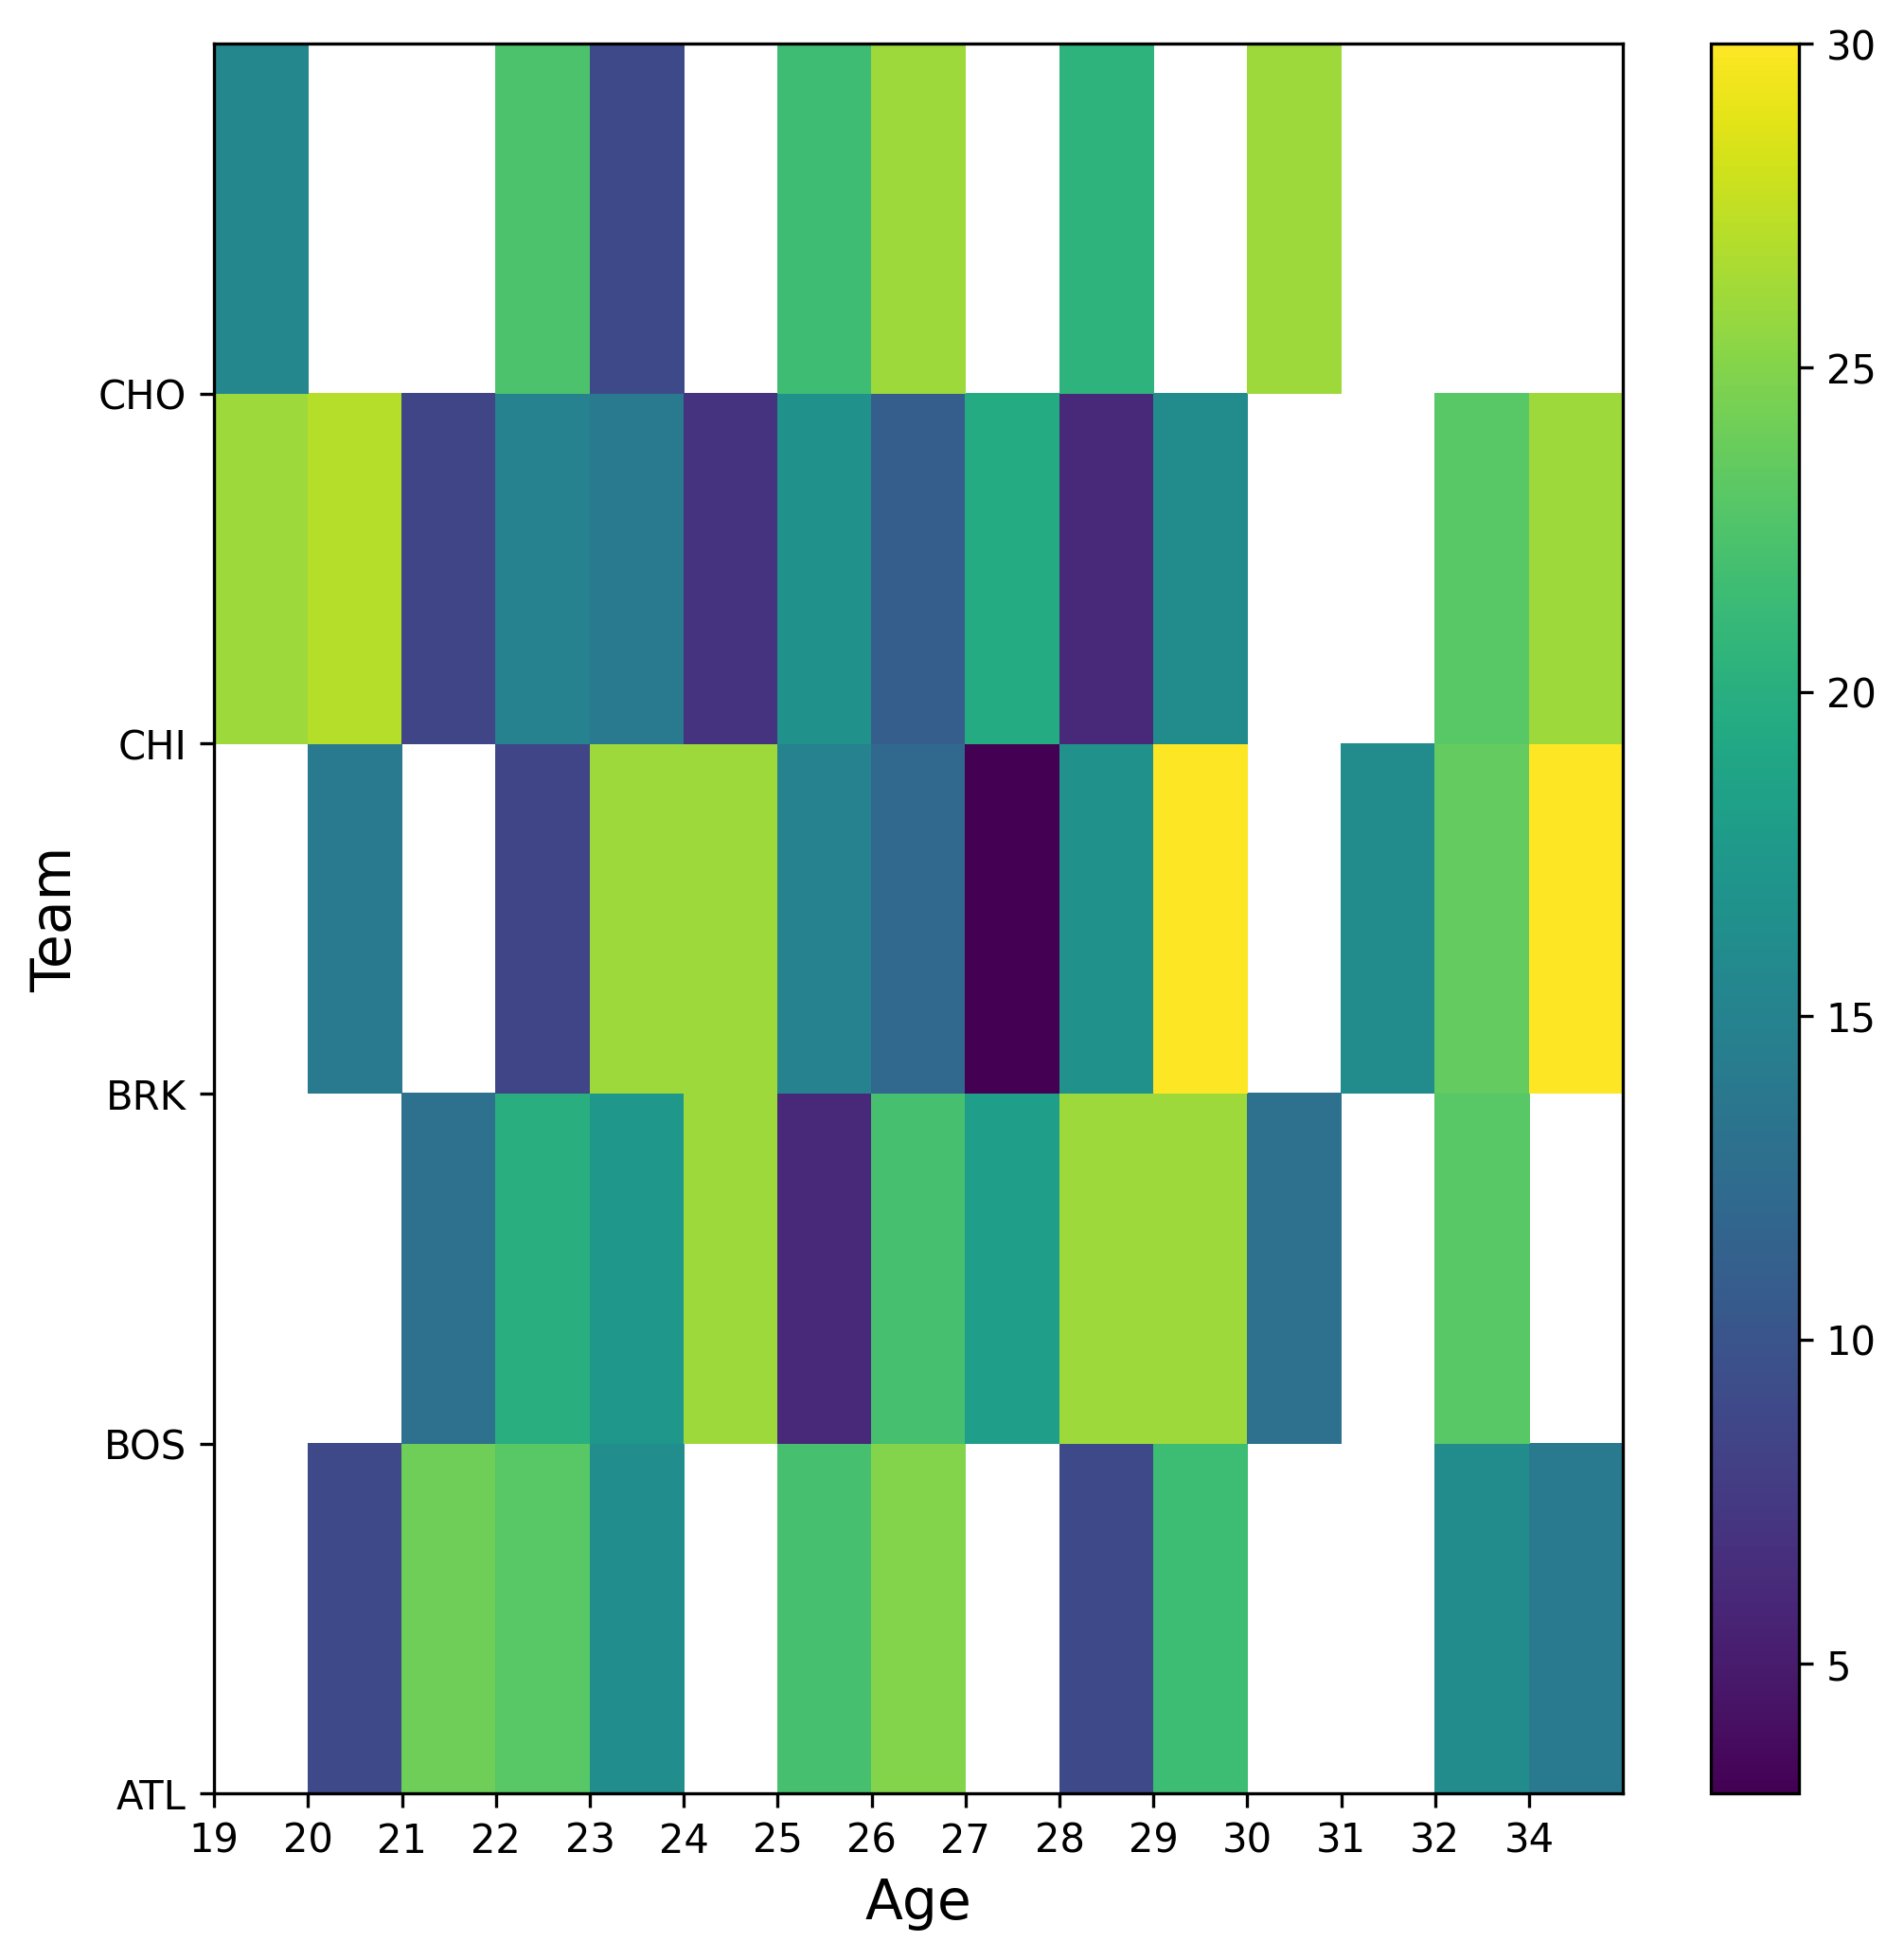

In [8]:
# 히트맵 시각화 V2

fig = plt.figure(figsize=(8,8))
fig.set_facecolor('white')

plt.pcolor(df2.values)
# x축 컬럼 설정
plt.xticks(range(len(df2.columns)),df2.columns)
# y축 컬럼 설정
plt.yticks(range(len(df2.index)), df2.index)
# x축 레이블 설정
plt.xlabel('Age', fontsize=14)
# y축 레이블 설정
plt.ylabel('Team', fontsize=14)
plt.colorbar()
plt.show()

In [9]:
# 방사형 차트를 위한 인덱스 초기화
df3 = df1.reset_index()
df3.head()

,Tm,ORB%,TRB%,AST%,BLK%,USG%
0,ATL,5.250000,10.400000,13.893750,1.718750,18.412500
1,BOS,5.681250,10.362500,12.881250,2.437500,18.325000
2,BRK,4.394737,10.547368,15.210526,2.147368,18.868421
3,CHI,4.482353,10.976471,13.500000,1.405882,17.582353
4,CHO,7.628571,11.742857,14.900000,2.764286,19.357143


<ipython-input-10-8d7ed5931b0c>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(df3.index))


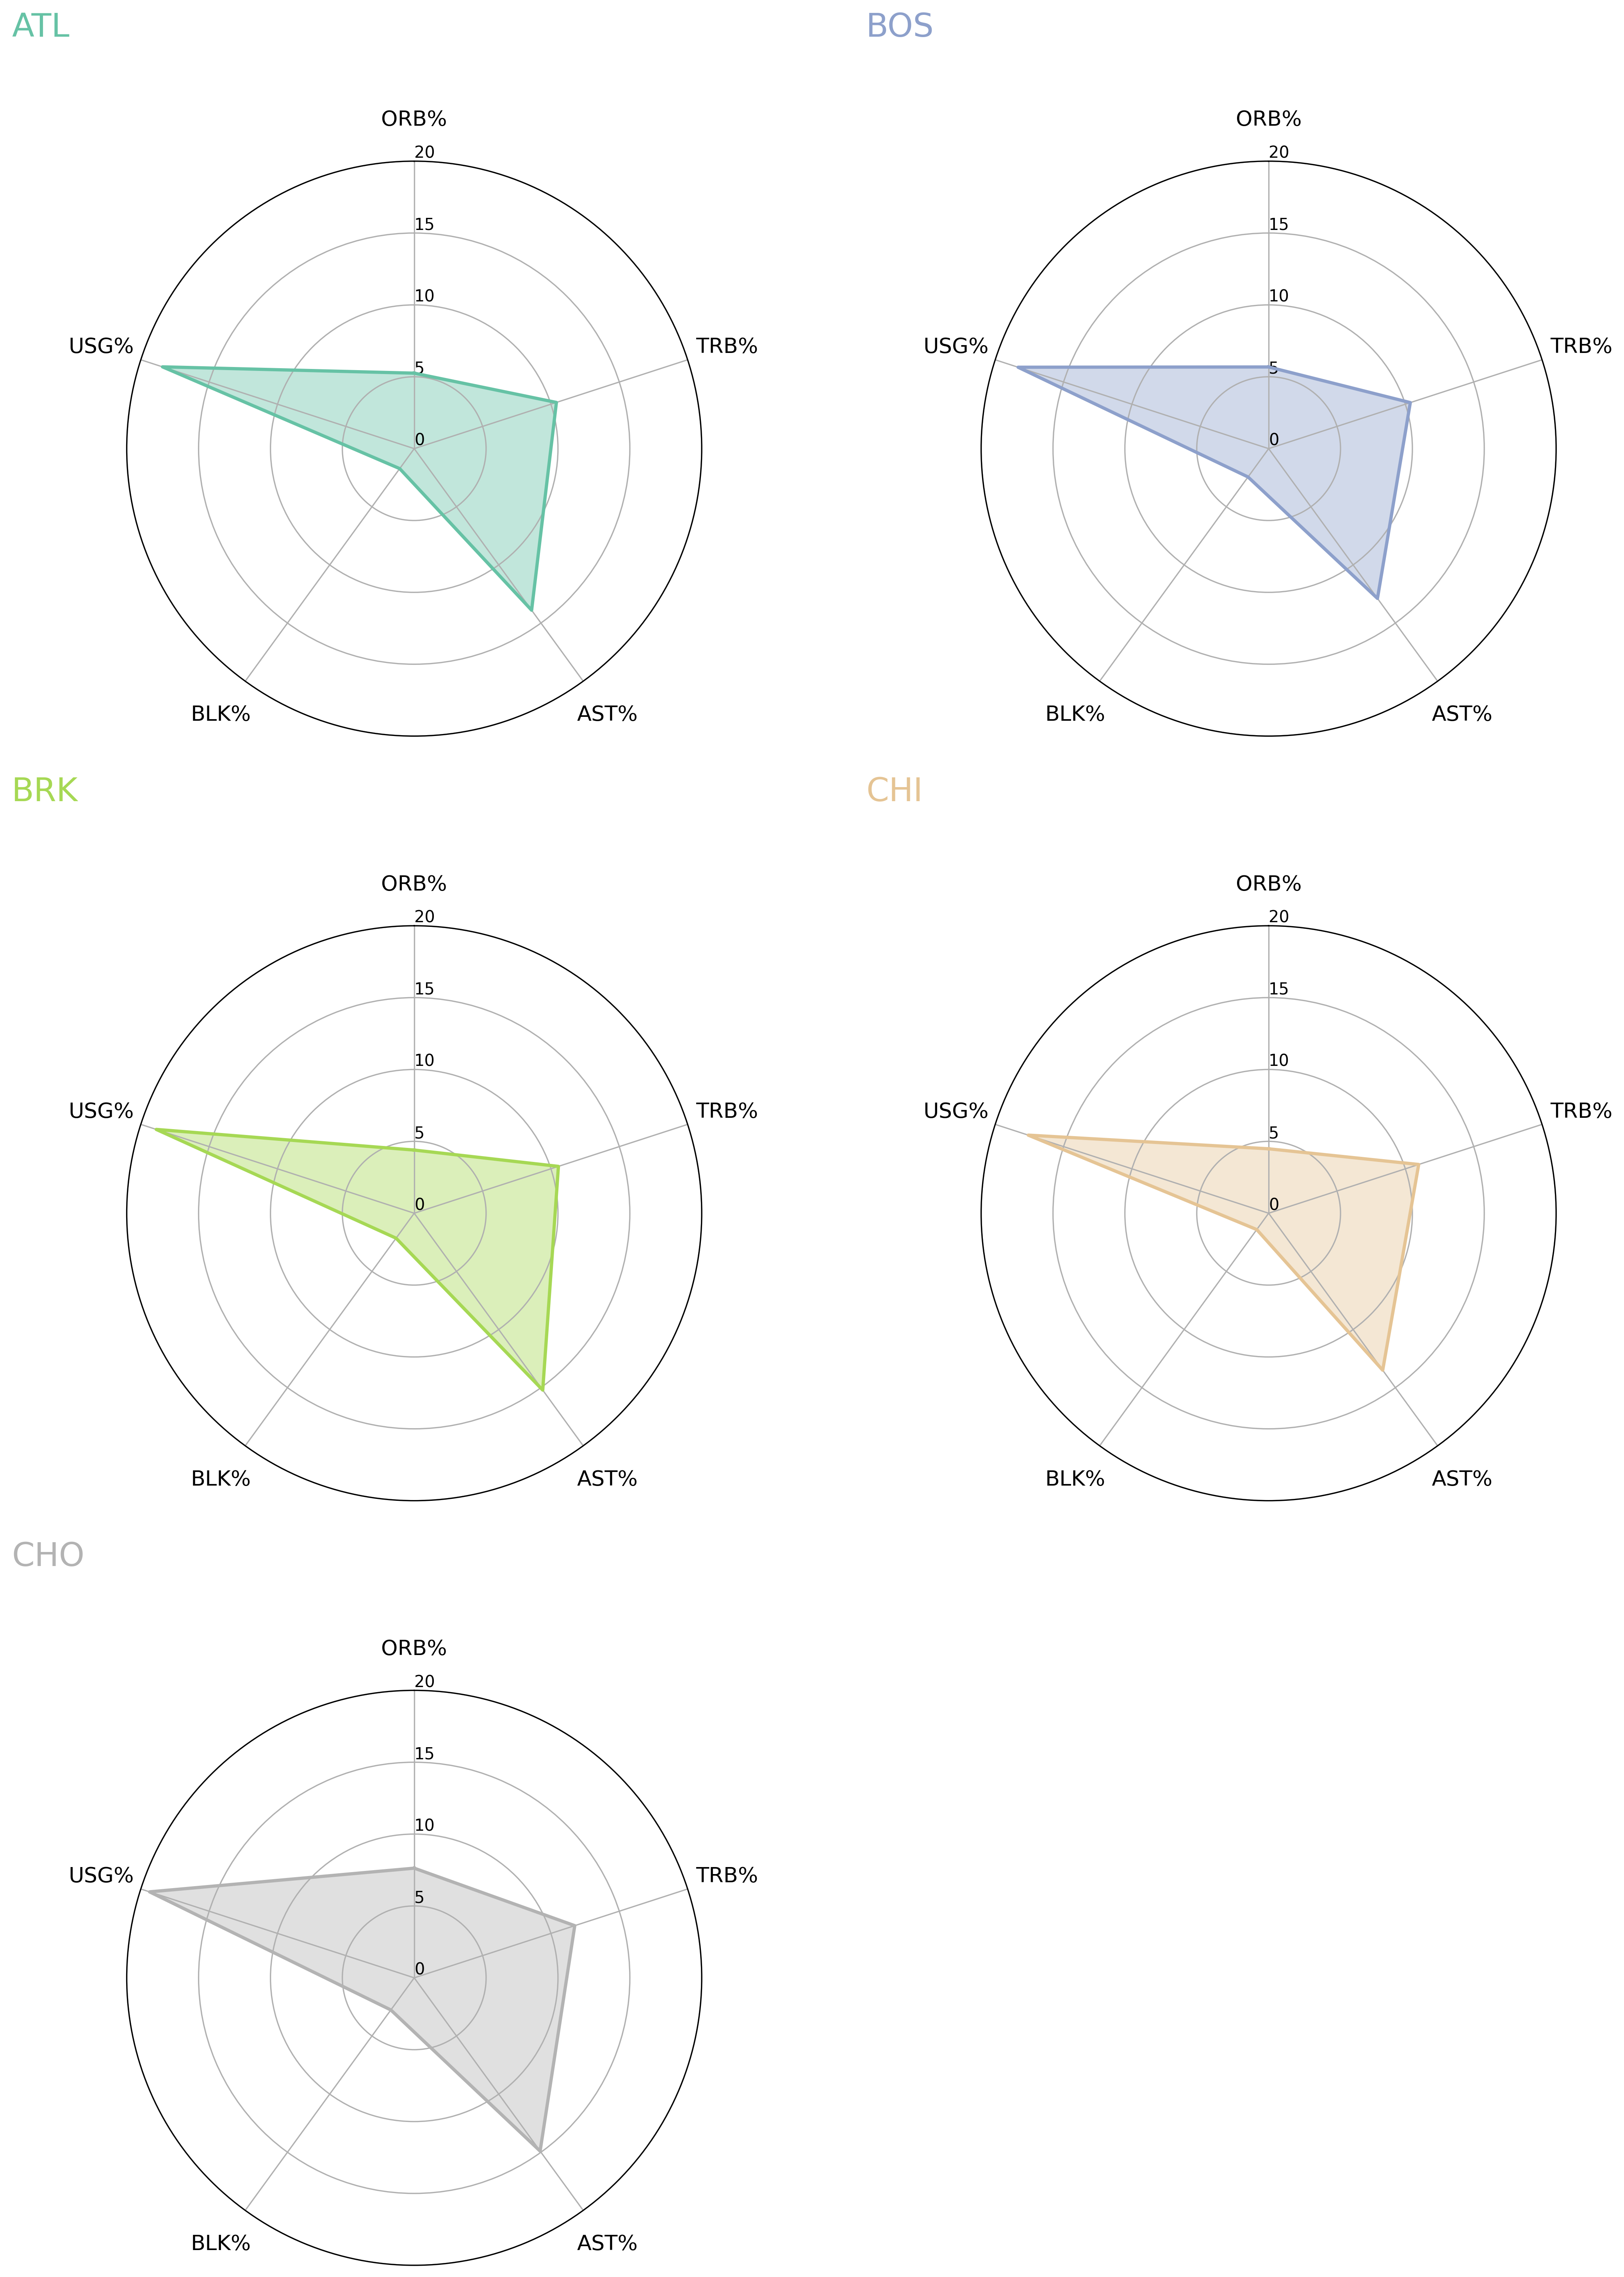

In [10]:
# 방사형 차트 - 하나씩 시각화

labels = df3.columns[1:]
num_labels = len(labels)

# 등분점 생성
angles = [x/float(num_labels)*(2*pi) for x in range(num_labels)]
angles += angles[:1] # 시작점 생성

my_palette = plt.cm.get_cmap("Set2", len(df3.index))

fig = plt.figure(figsize=(15,20))
fig.set_facecolor('white')

for i, row in df3.iterrows():
    color = my_palette(i)
    data = df3.iloc[i].drop('Tm').tolist()
    data += data[:1]

    ax = plt.subplot(3,2,i+1, polar=True)
    # 시작점 설정
    ax.set_theta_offset(pi / 2)
    # 시계방향 설정
    ax.set_theta_direction(-1)

    # 각도 축 눈금 생성
    plt.xticks(angles[:-1], labels, fontsize=13)
    # 각 축과 눈금 사이 여백생성
    ax.tick_params(axis='x', which='major', pad=15)
    # 반지름 축 눈금 라벨 각도 0으로 설정
    ax.set_rlabel_position(0)
    # 반지름 축 눈금 설정
    plt.yticks([0,5,10,15,20],['0','5','10','15','20'], fontsize=10)
    plt.ylim(0,20)

    # 방사형 차트 출력
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    # 도형 안쪽 색상 설정
    ax.fill(angles, data, color=color, alpha=0.4)
    # 각 차트의 제목 생성
    plt.title(row.Tm, size=20, color=color,x=-0.2, y=1.2, ha='left')
# 차트 간 간격 설정
plt.tight_layout(pad=3)
plt.show()

<ipython-input-11-6e93d413d62c>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(df3.index))


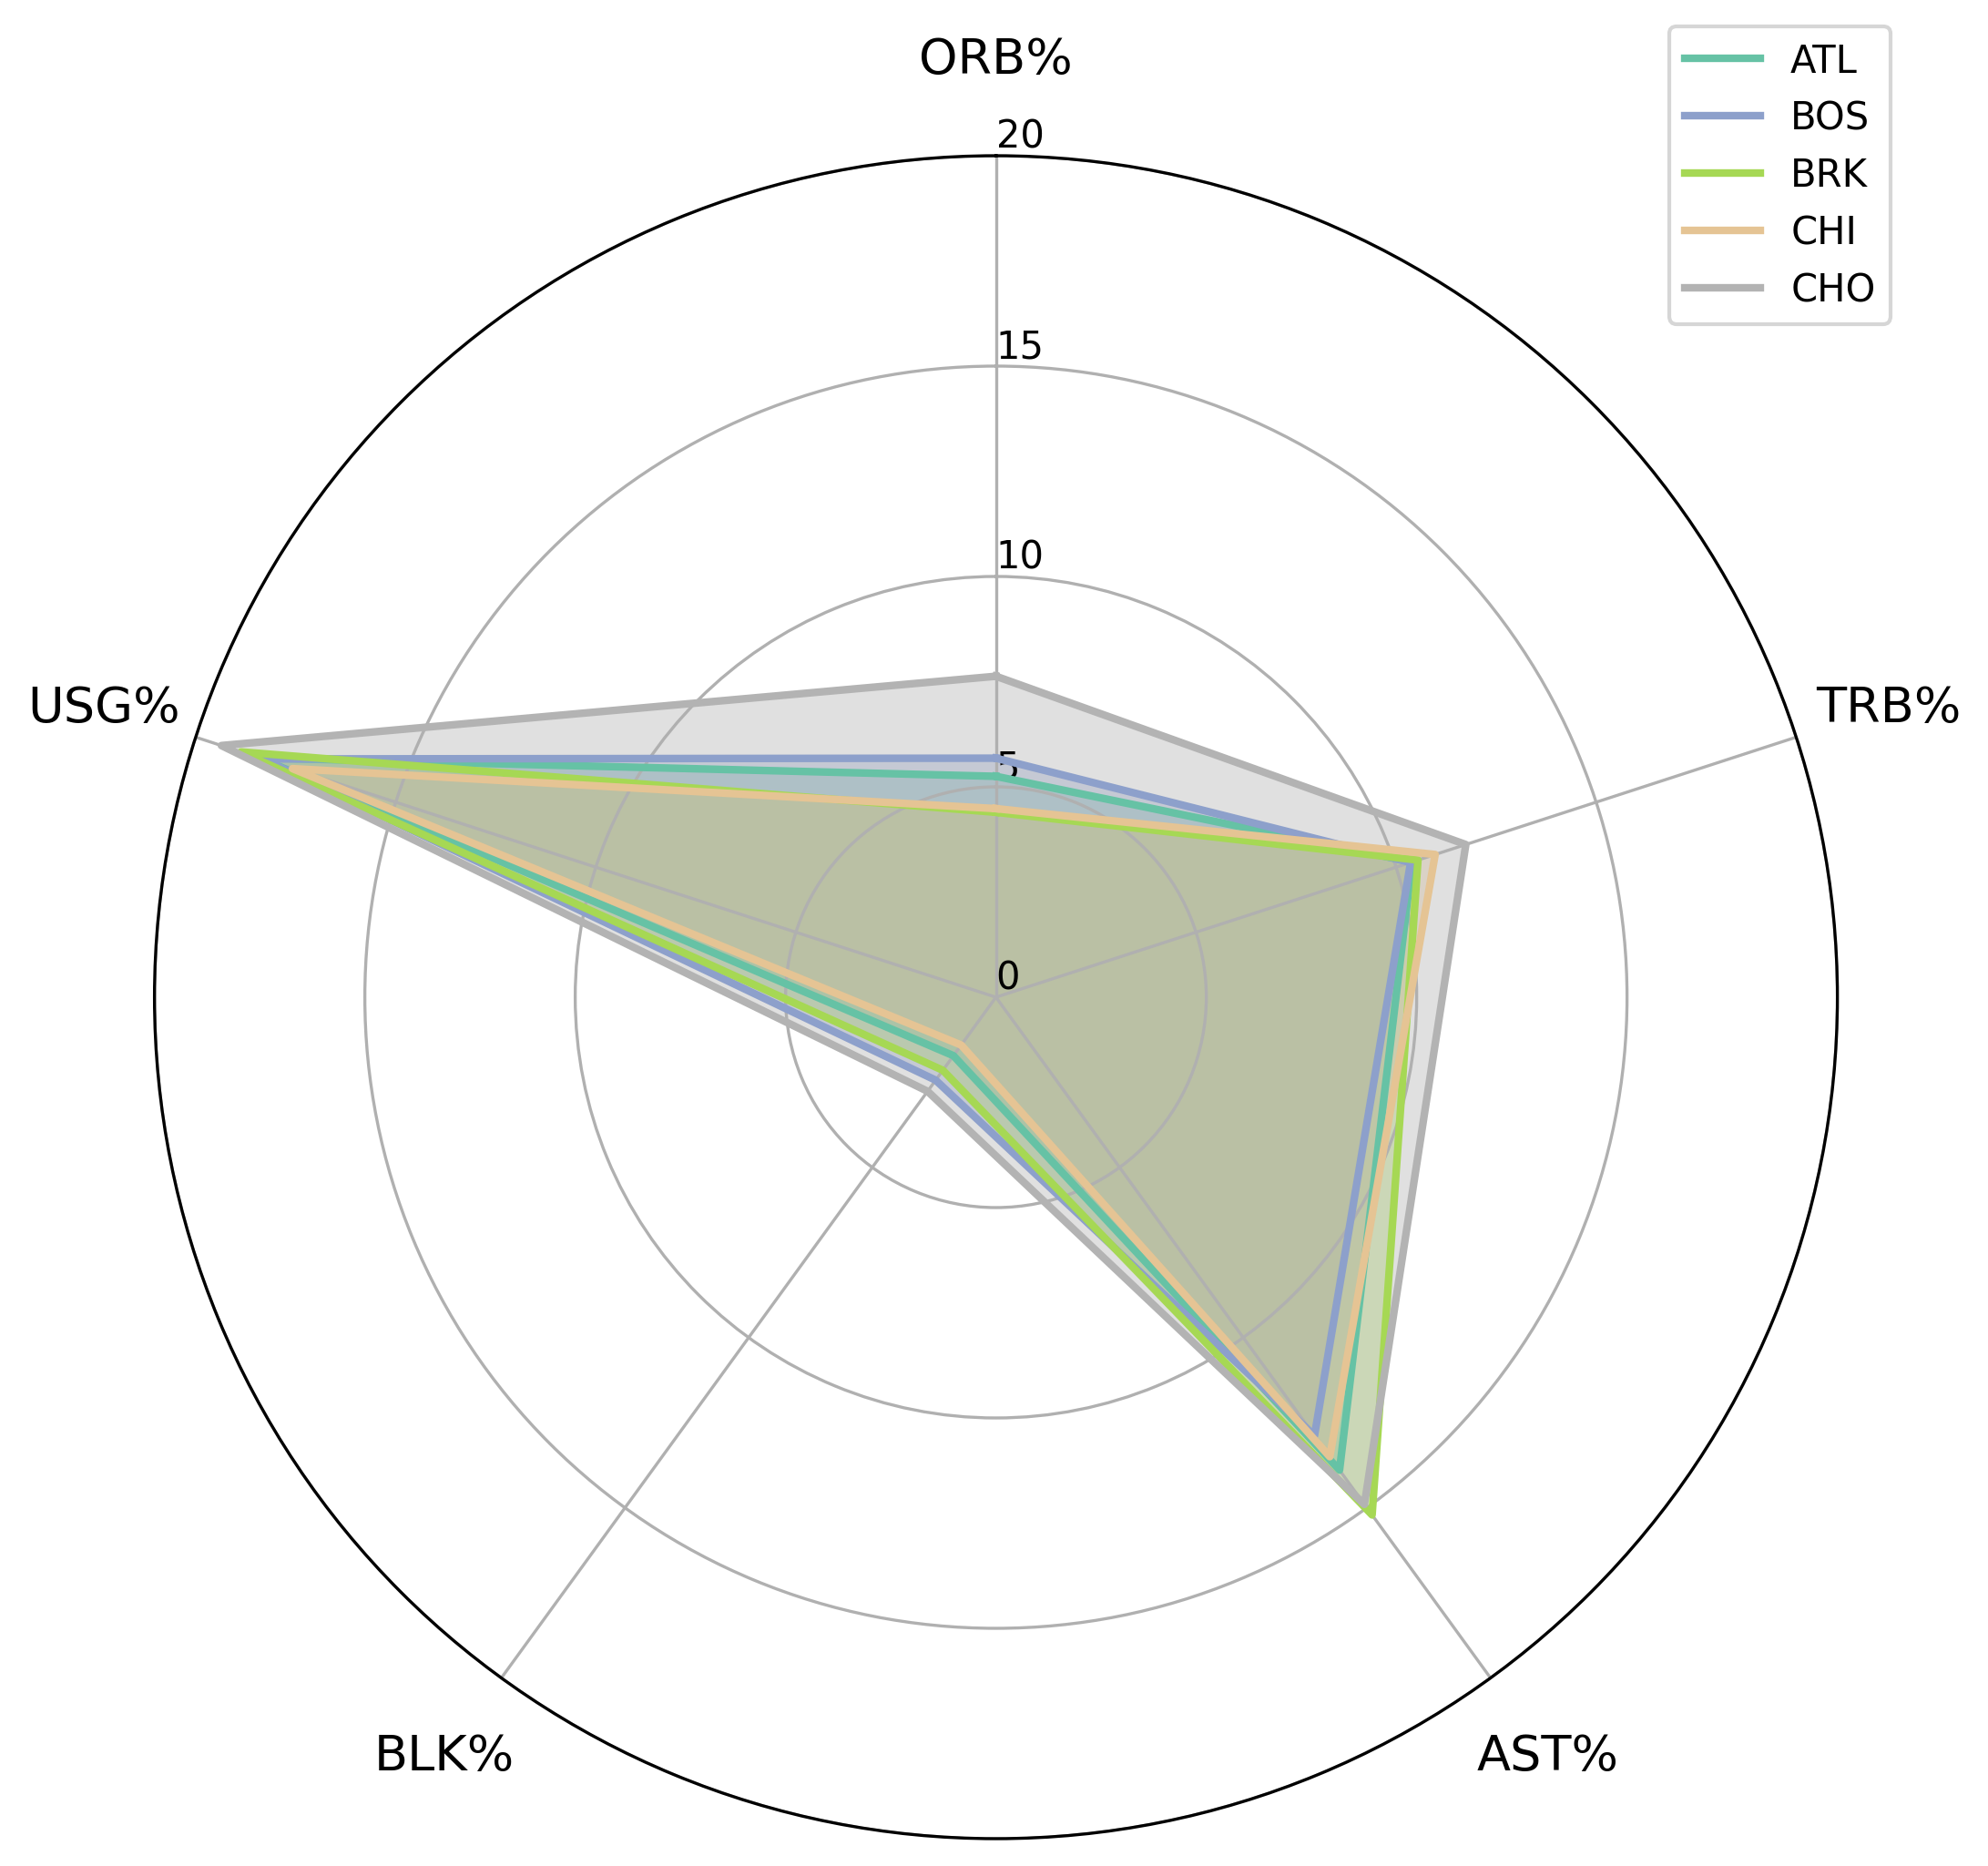

In [11]:
# 방사형 차트 - 한번에 시각화

labels = df3.columns[1:]
num_labels = len(labels)

# 등분점 생성
angles = [x/float(num_labels)*(2*pi) for x in range(num_labels)]
# 시작점 생성
angles += angles[:1]

my_palette = plt.cm.get_cmap("Set2", len(df3.index))

fig = plt.figure(figsize=(8,8))
fig.set_facecolor('white')
ax = fig.add_subplot(polar=True)
for i, row in df3.iterrows():
    color = my_palette(i)
    data = df3.iloc[i].drop('Tm').tolist()
    data += data[:1]

    # 시작점
    ax.set_theta_offset(pi / 2)
    # 시계방향 설정
    ax.set_theta_direction(-1)

    # 각도 축 눈금 생성
    plt.xticks(angles[:-1], labels, fontsize=13)
    # 각 축과 눈금 사이 여백생성
    ax.tick_params(axis='x', which='major', pad=15)
    # 반지름 축 눈금 라벨 각도 0으로 설정
    ax.set_rlabel_position(0)
    # 반지름 축 눈금 설정
    plt.yticks([0,5,10,15,20],['0','5','10','15','20'], fontsize=10)
    plt.ylim(0,20)

    # 방사형 차트 출력
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid', label=row.Tm)
    # 도형 안쪽 색상 설정
    ax.fill(angles, data, color=color, alpha=0.4)

plt.legend(loc=(0.9,0.9))
plt.show()

<Axes: >

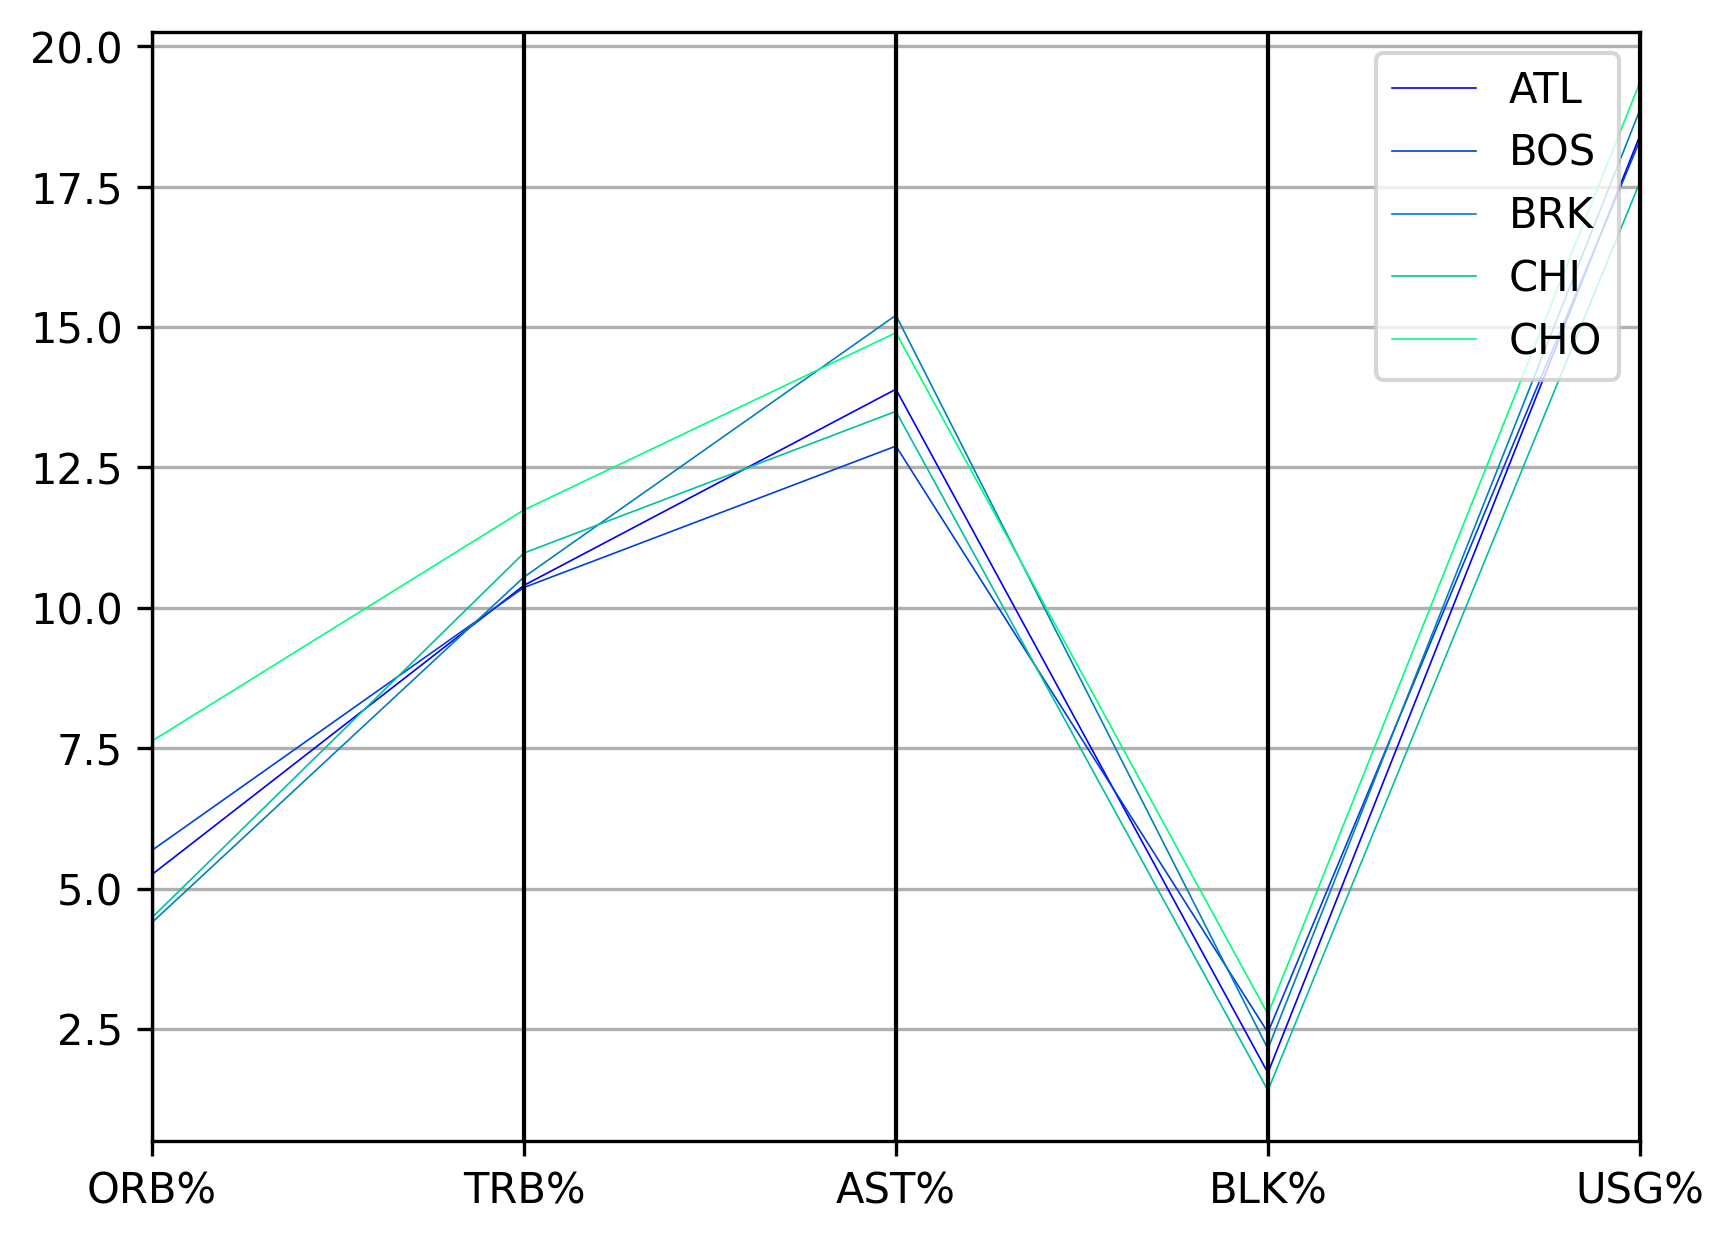

<Figure size 4800x2400 with 0 Axes>

In [20]:
# 팀 기준 평행 좌표 그래프 생성

fig,axes = plt.subplots()
plt.figure(figsize=(16,8)) # 그래프 크기 조정
parallel_coordinates(df3,'Tm',ax=axes, colormap='winter',linewidth = "0.4")